In [31]:
import pandas as pd
from PIL import Image
from io import BytesIO
from IPython.display import display
import requests

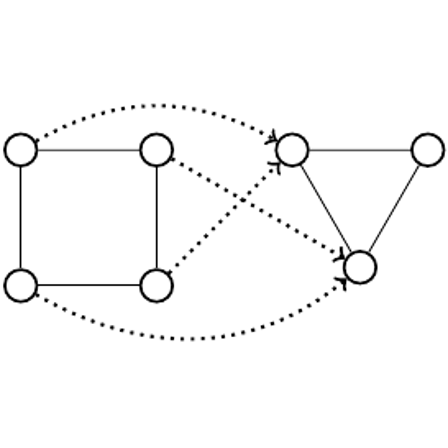

In [32]:
base_path = "/home/jonas/Datasets/TikZ/DaTikZ-V4"
file_path = f"{base_path}/train-00000.parquet"
df = pd.read_parquet(file_path)
row_num = 1
data = df["png_image"][row_num]
img = Image.open(BytesIO(data["bytes"]))
display(img)

In [33]:
caption = df["caption"][row_num]

In [ ]:
vlm_description = df["vlm_description"][row_num]

In [35]:
url = "http://localhost:8002/tikzero"

response = requests.post(url, json={"text": caption})
response.raise_for_status()

tikz = response.json()["tikz"]

with open("output_caption.tex", "w", encoding="utf-8") as f:
    f.write(tikz)

print(tikz)

\documentclass[11pt]{article}
\usepackage[utf8]{inputenc}
\usepackage[T1]{fontenc}
\usepackage{amsmath, amssymb, color}
\usepackage[T1]{fontenc}
\usepackage{tikz}
\usetikzlibrary{decorations}
\usetikzlibrary{shapes}
\usetikzlibrary{arrows}
\usetikzlibrary{positioning}
\usetikzlibrary{calc}

\begin{document}

\begin{tikzpicture}[->,every node/.style={circle,draw},line width=1pt]
  \node[ellipse,draw] (1) at (0,0) {1};
  \node (2) at (0,1.7) {$2$};
  \node (3) at (2,1.7) {$3$};
  \node (4) at (2,0) {$4$}; 
\foreach \from/\to in {1/2,2/3,3/4,4/1,1/3}
\draw (\from) -- (\to);   
\path[every node/.style={font=\sffamily\small}]
    (1) edge [bend right] node [left] {} (4);
\end{tikzpicture}

\end{document}


In [36]:
url = "http://localhost:8002/tikzero"

response = requests.post(url, json={"text": vlm_description})
response.raise_for_status()

tikz = response.json()["tikz"]

with open("output_vlm_description.tex", "w", encoding="utf-8") as f:
    f.write(tikz)

print(tikz)

\documentclass{article}
\usepackage{tikz}
\usetikzlibrary{calc}

\begin{document}

\begin{tikzpicture}
  \node[shape=circle,minimum size=1cm,draw=black] (A) at (0,0) {$0$};
  \node[shape=circle,minimum size=1cm,draw=black] (B) at (0,2) {$1$};
  \node[shape=circle,minimum size=1cm,draw=black] (C) at (2,2) {$2$};
  \node[shape=circle,minimum size=1cm,draw=black] (D) at (2,0) {$3$};
  \draw[line width=0.5mm] (A) -- (B);
  \draw[line width=0.5mm] (B) -- (C);
  \draw[line width=0.5mm] (C) -- (D);
  \draw[line width=0.5mm] (A) -- (D);
  \draw[line width=0.5mm,dotted,->] (2.1,1.9) to[out=310,in=100] (1.9,0.1);
  \draw[line width=0.5mm,dotted,<-] (0.1,0.1) to[out=70,in=250] (1.1,1.9);
  \draw[line width=0.5mm,dotted,->] (2.1,-0.1) to[out=310,in=250] (1.1,-0.1);
  \draw[line width=0.5mm,dotted,<-] (-0.1,-0.1) to[out=70,in=110] (-0.1,1.1);
  \draw[line width=0.5mm,dotted,->] (1.9,2.1) to[out=270,in=70] (1.1,1.9);
  \draw[line width=0.5mm,dotted,<-] (0.1,1.9) to[out=290,in=110] (0.9,1.1);
\end{ti